# Application laboratory: independent cascades as dynamic graphical models

The independent-cascade model describes information, infection, or failure spreading on a network. Newly activated nodes get one opportunity to activate each inactive neighbor. The process is local and stochastic, so its trajectory law is naturally represented by a dynamic graphical model.

We compare exact propagation on a small graph with Monte Carlo simulation. The example makes a useful distinction: the physical/social interaction graph is static, but uncertainty propagates in time on an unrolled graph.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from collections import defaultdict
G=nx.Graph(); G.add_edges_from([(0,1),(0,2),(1,3),(2,3),(2,4),(3,5),(4,5)])
pedge={tuple(sorted(e)):p for e,p in zip(G.edges(),[.45,.35,.50,.30,.55,.40,.50])}
T=5; seed=frozenset([0])
# Exact distribution over (active, frontier).
d={(seed,seed):1.0}; exact=np.zeros((T+1,len(G))); exact[0,0]=1
for t in range(T):
    nd=defaultdict(float)
    for (active,front),prob in d.items():
        candidates=sorted(set().union(*(set(G.neighbors(u)) for u in front))-set(active)) if front else []
        q=[]
        for v in candidates:
            fail=1.0
            for u in front:
                if G.has_edge(u,v): fail*=1-pedge[tuple(sorted((u,v)))]
            q.append(1-fail)
        for mask in range(1<<len(candidates)):
            new=set(); pr=1.0
            for k,v in enumerate(candidates):
                if mask>>k &1: new.add(v); pr*=q[k]
                else: pr*=1-q[k]
            na=frozenset(set(active)|new); nf=frozenset(new); nd[(na,nf)]+=prob*pr
    d=nd
    for (active,front),prob in d.items():
        for v in active: exact[t+1,v]+=prob
# MC -- vectorized over independent cascades so that the stress tests below remain lightweight.
def simulate_cascade_marginals(sample_count, rng_local):
    n = len(G)
    active = np.zeros((sample_count, n), dtype=bool)
    front = np.zeros_like(active)
    active[:, 0] = True
    front[:, 0] = True
    estimate = np.zeros_like(exact)
    estimate[0] = active.mean(axis=0)
    for t in range(T):
        new = np.zeros_like(active)
        for v in G.nodes:
            eligible = ~active[:, v]
            fail = np.ones(sample_count)
            for u in G.neighbors(v):
                p = pedge[tuple(sorted((u, v)))]
                fail *= np.where(front[:, u], 1.0 - p, 1.0)
            q = 1.0 - fail
            new[:, v] = eligible & (rng_local.random(sample_count) < q)
        active |= new
        front = new
        estimate[t + 1] = active.mean(axis=0)
    return estimate

S=40000
mc=simulate_cascade_marginals(S, RNG)
print('max exact/MC discrepancy',np.abs(exact-mc).max())


max exact/MC discrepancy 0.003925000000000012


/tmp/ipykernel_3766/1440664098.py:38: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)


Saved ch11_06_independent_cascade


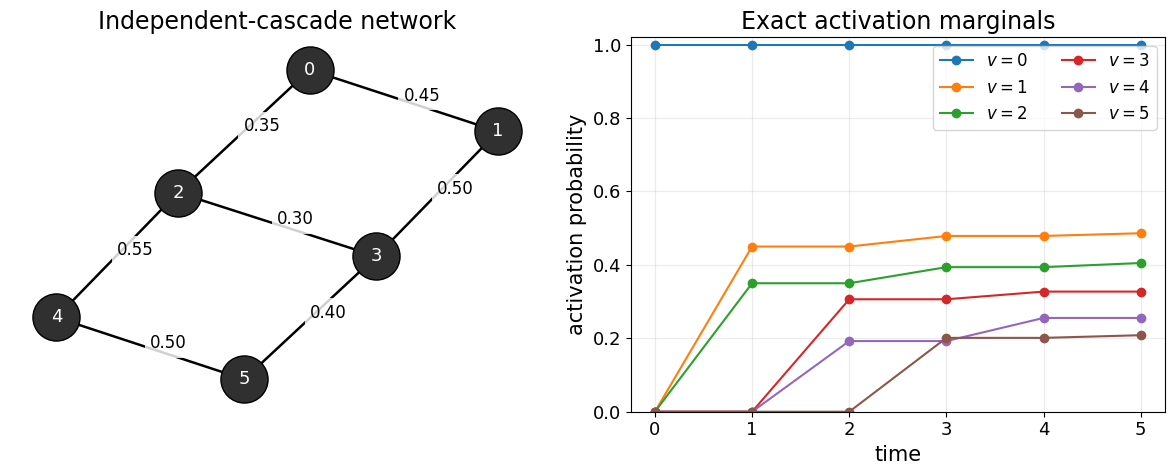

Saved ch11_06_cascade_mc_error


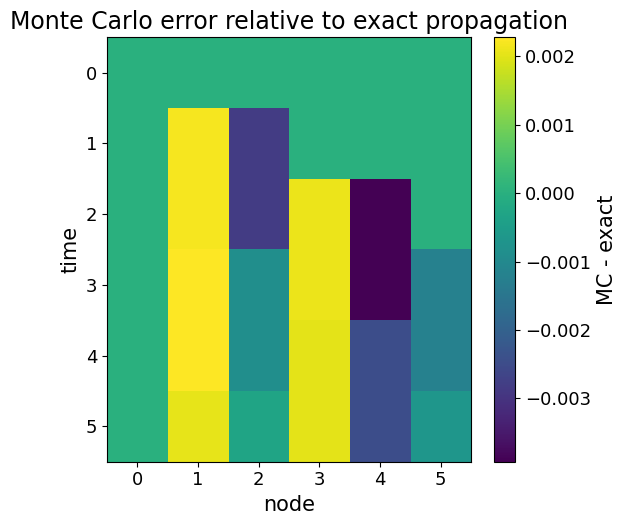

In [3]:
pos=nx.spring_layout(G,seed=4)
fig,axes=plt.subplots(1,2,figsize=(12,5))
draw_dark_nodes(G,pos,labels={i:str(i) for i in G},ax=axes[0],node_size=1150)
for e,p in pedge.items():
    mid=(np.array(pos[e[0]])+np.array(pos[e[1]]))/2; axes[0].text(*mid,f'{p:.2f}',fontsize=12,bbox=dict(facecolor='white',alpha=.82,edgecolor='none'))
axes[0].set_title('Independent-cascade network'); axes[0].axis('off')
for v in G.nodes: axes[1].plot(range(T+1),exact[:,v],marker='o',label=rf'$v={v}$')
axes[1].set_xlabel('time'); axes[1].set_ylabel('activation probability'); axes[1].set_ylim(0,1.02); axes[1].set_title('Exact activation marginals'); axes[1].legend(ncol=2); axes[1].grid(alpha=.25)
fig.tight_layout(); save_figure(fig,'ch11_06_independent_cascade'); plt.show()

fig,ax=plt.subplots(figsize=(6,5.5)); im=ax.imshow(mc-exact,aspect='auto'); ax.set_xlabel('node'); ax.set_ylabel('time'); ax.set_xticks(range(len(G))); ax.set_yticks(range(T+1)); ax.set_title('Monte Carlo error relative to exact propagation'); fig.colorbar(im,ax=ax,label='MC - exact'); fig.tight_layout(); save_figure(fig,'ch11_06_cascade_mc_error'); plt.show()

## Stress test: Monte Carlo is unbiased in principle but unreliable at small sample size

The exact finite-state propagation above provides a rare ground truth for a sampling approximation. We therefore use it to ask not only whether Monte Carlo eventually works, but how badly it can fail before the asymptotic regime is reached.

For each sample size $S$, we repeat the Monte Carlo estimate with independent random seeds and record the maximum marginal error over all nodes and times. The median error follows the expected $S^{-1/2}$ trend, while the upper tail shows why a single apparently reasonable Monte Carlo run can still be misleading.

Saved ch11_06_mc_sample_size_stress


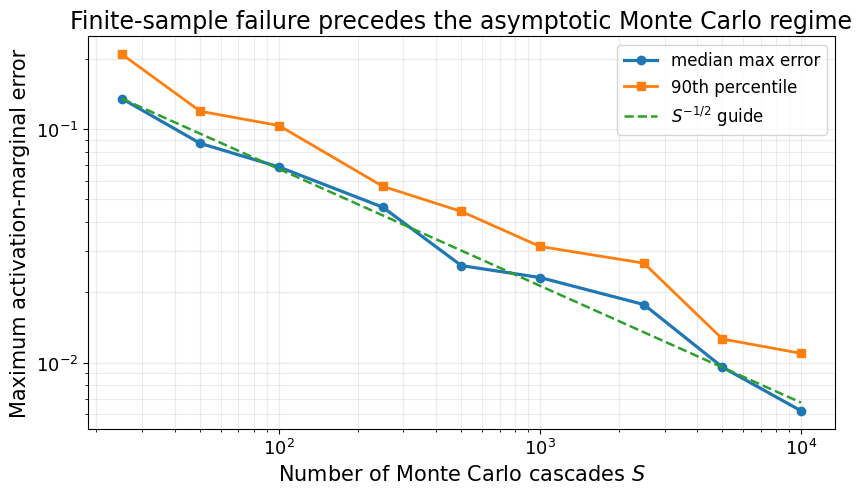

In [4]:
def cascade_mc_error(sample_count, seed_value):
    rng_local = np.random.default_rng(seed_value)
    estimate = simulate_cascade_marginals(sample_count, rng_local)
    return np.max(np.abs(estimate - exact))

sample_grid = np.array([25, 50, 100, 250, 500, 1000, 2500, 5000, 10000])
replicates = 14
errors_by_s = []
for idx, sample_count in enumerate(sample_grid):
    errors = [
        cascade_mc_error(int(sample_count), 3000 + 100 * idx + rep)
        for rep in range(replicates)
    ]
    errors_by_s.append(errors)
errors_by_s = np.asarray(errors_by_s)
median_error = np.median(errors_by_s, axis=1)
q90_error = np.quantile(errors_by_s, 0.90, axis=1)

fig, ax = plt.subplots(figsize=(8.7, 5.2))
ax.loglog(sample_grid, median_error, marker="o", linewidth=2.3, label="median max error")
ax.loglog(sample_grid, q90_error, marker="s", linewidth=2.0, label="90th percentile")
guide = median_error[0] * np.sqrt(sample_grid[0] / sample_grid)
ax.loglog(sample_grid, guide, linestyle="--", linewidth=1.8, label=r"$S^{-1/2}$ guide")
ax.set_xlabel("Number of Monte Carlo cascades $S$")
ax.set_ylabel("Maximum activation-marginal error")
ax.set_title("Finite-sample failure precedes the asymptotic Monte Carlo regime")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch11_06_mc_sample_size_stress")
plt.show()


## Exercises

1. Estimate influence spread for every possible seed node and identify the best single seed.
2. Replace one edge probability by an unknown parameter and derive its likelihood from observed cascades.
3. Compare the independent-cascade dynamics with single-spin Glauber dynamics. Which conditional dependences are similar, and which are fundamentally different?
4. Introduce interventions that block selected edges. Formulate influence minimization as a control problem on the dynamic graphical model.